# Goal

Model cell differentiation trajectories using palantir (via `scanpy.external`) and CellRank, with a focus on whether cluster 2 is a transitory state feeding into clusters 1 and 3.

# Import

In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/09_treg_depletion_agonist_antibody_SIG19"

import numpy as np
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import palantir
import cellrank as cr
import os
import re
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (3,3)
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False

import sys
sys.path.insert(0, f'{REPO_DIR}/functions')
import scanpy_custom as scc

%load_ext autoreload
%autoreload 2

In [2]:
output_dir = f'{OUTS_DIR}/cellrank_manuscript'
os.makedirs(output_dir, exist_ok=True)

In [3]:
rna = sc.read_h5ad(f'{IMPORTS_DIR}/SIG19/scvi_outs/SIG19_DTR_CD4T_iLN_scvi.h5ad')

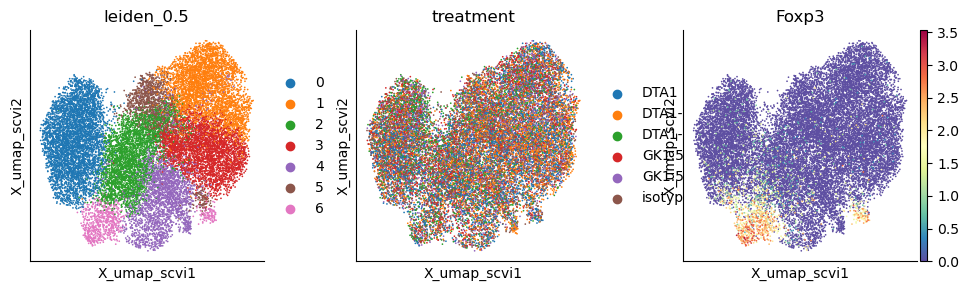

In [4]:
sc.pl.embedding(rna, basis='X_umap_scvi', color=['leiden_0.5','treatment','Foxp3'], layer='log1p_norm')

# Subset and Recalculate PCA

Here, I am removing Treg cells because they are likely either thymic derived or residual Treg cells form the DT ablation. Thus, they do not really belong in the naive to effector CD4 T cell differentiation axis.

In [5]:
# remove Tregs cluster
rna = rna[rna.obs['leiden_0.5'] != '6']

In [ ]:
# recalculate PCA
sc.tl.pca(rna, n_comps=50)
sc.pp.neighbors(rna)

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


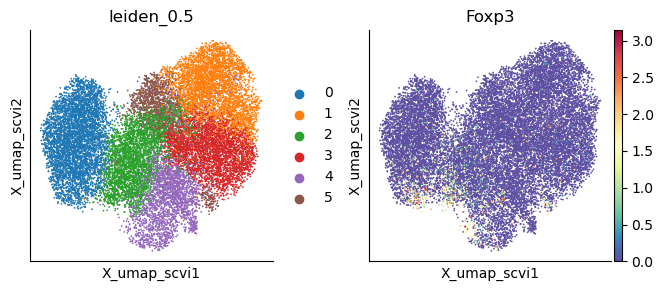

In [7]:
sc.pl.embedding(rna, basis='X_umap_scvi', color=['leiden_0.5','Foxp3'], layer='log1p_norm')

# Add Signaling Activity Scores

Here, we add single cell activity scores derived from our Signal-seq inference model

In [8]:
# import activity scores for SIG19 iLN scvi data
scores = pd.read_parquet(f"{IMPORTS_DIR}/SIG13/analysis_outs/inference_model_disease_sc/activity_scores_sig19_iln.parquet")
scores.set_index('cell_id', inplace=True)

# filter for activity columns
scores = scores.filter(regex='^activity_')

# merge with rna obs
merge_obs = rna.obs.merge(scores, how='left', left_index=True, right_index=True)

In [9]:
rna.obs = merge_obs.copy()

In [10]:
rna.obs.columns

Index(['tissue', 'n_genes_by_counts', 'total_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt',
       'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo',
       'pct_counts_ribo', 'log1p_total_counts_ribo', 'log10_genes_per_umi',
       'S_score', 'G2M_score', 'phase', 'n_counts', 'n_genes', 'doublet_score',
       'predicted_doublet', 'hashtag_code', 'cage', 'mouse', 'treatment',
       'leiden', 'experiment', 'sex', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5',
       'leiden_2.0', 'leiden_0.75', 'activity_TGFB1_IL21_c',
       'activity_TGFB1_TNFSF18_c', 'activity_TGFB1_IL4_c',
       'activity_IL27_IL18_c', 'activity_IL21_IL1B_c', 'activity_TNF_CCL19_c',
       'activity_IL21_CCL21A_c', 'activity_IL7_TNFSF18_c',
       'activity_IL4_CCL19_c', 'activity_IL2_TNFSF4_c',
       'activity_IL6_TNFSF18_c', 'activity_IL2_TNFSF18_c',
       'activity_IL4_TNFSF18_c', 'activity_TNF_TNFSF4_c',
       'activity_IL2_IFNB1_c', 'activity_IL4_IFNB1_c', 'acti

# Construct Palantir Object

We use palantir to calculate pseudotime. We define the distinct effector populations as terminal states for the purposes of entropy calculation.

In [11]:
# Construct diffusion maps using Palantir
palantir.utils.run_diffusion_maps(rna, pca_key='X_pca', n_components = 10)
palantir.utils.determine_multiscale_space(rna)
palantir.utils.run_magic_imputation(rna)

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 91727111 stored elements and shape (19121, 12055)>

In [12]:
start_cell = palantir.utils.early_cell(rna, celltype='0', celltype_column='leiden_0.5')
terminal_cell = palantir.utils.find_terminal_states(rna,
                                                    celltypes=['1','3','4'],
                                                    celltype_column='leiden_0.5',
                                                    fallback_seed=42)

Using 25218 for cell type 0 which is min in diffusion component 0.
Using 11806 for cell type 1 which is max in diffusion component 2.
Using 14648 for cell type 3 which is max in diffusion component 0.
Using 14560 for cell type 4 which is max in diffusion component 1.


The selected clusters are well captured by unique diffusion components, which indicates their suitability as terminal states.

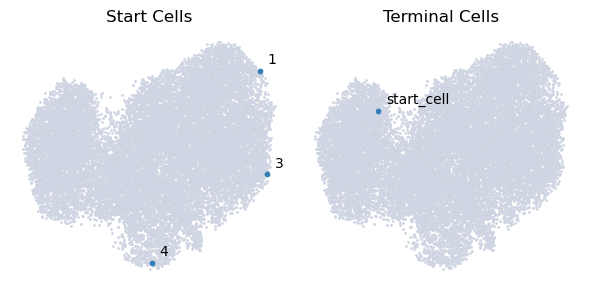

In [13]:
# plot start and terminal states
fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # 1 row, 2 columns

palantir.plot.highlight_cells_on_umap(rna, {start_cell: 'start_cell'}, ax=axes[1], embedding_basis = 'X_umap_scvi')
axes[0].set_title("Start Cells")
palantir.plot.highlight_cells_on_umap(rna, terminal_cell, ax=axes[0], embedding_basis = 'X_umap_scvi')
axes[1].set_title("Terminal Cells")

plt.tight_layout()
plt.show()

In [14]:
palantir.core.run_palantir(rna,
                           start_cell,
                           terminal_states=terminal_cell)

Sampling and flocking waypoints...
Time for determining waypoints: 0.00027544895807902017 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.1460099697113037 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9997
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


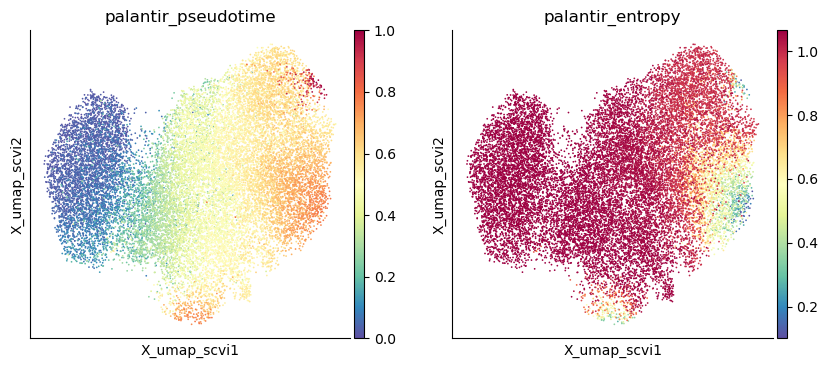

In [15]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
sc.pl.embedding(rna, basis='X_umap_scvi', color='palantir_pseudotime', ax=ax[0], show=False)
sc.pl.embedding(rna, basis='X_umap_scvi', color='palantir_entropy', ax=ax[1], show=False)
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_pseudotime_umap.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_pseudotime_umap.png'), bbox_inches='tight')

# Calculate and Plot Palantir Trajectories

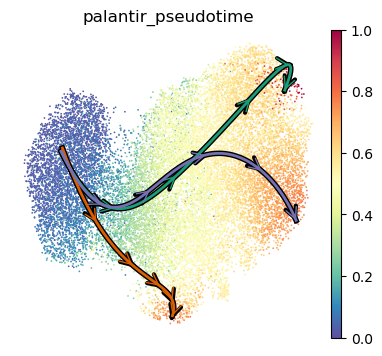

In [16]:
masks = palantir.presults.select_branch_cells(rna, q=.01, eps=.01)

palantir.plot.plot_trajectories(rna, embedding_basis = 'X_umap_scvi',
                                palantir_fates_colors=["#1B9E77FF", "#D95F02FF", "#7570B3FF", "#E7298AFF"],
                                figsize=(4.5,4), show_legend = False)
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_trajectories_umap.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_trajectories_umap.png'), bbox_inches='tight')

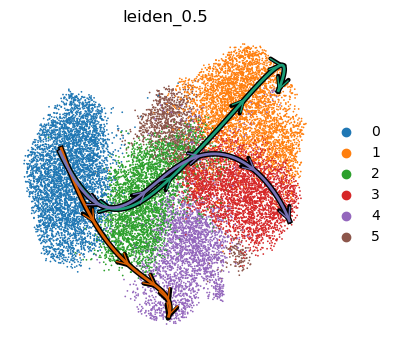

In [17]:
masks = palantir.presults.select_branch_cells(rna, q=.01, eps=.01)

palantir.plot.plot_trajectories(rna, embedding_basis = 'X_umap_scvi',
                                palantir_fates_colors=["#1B9E77FF", "#D95F02FF", "#7570B3FF", "#E7298AFF"],
                                figsize=(4,4), show_legend = False, cell_color = 'leiden_0.5')
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_trajectories_byCluster_umap.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_trajectories_byCluster_umap.png'), bbox_inches='tight')

In [18]:
def plot_pseudotime_cluster_freq(rna, branch='1', treatments=None, n_bins=20,
                                 cluster_col='leiden_0.5', ax=None):
    treatments = treatments or ['isotype', 'DTA1', 'GK1.5-BGo', 'DTA1-BGo']
    branch_mask = rna.obsm['branch_masks'][branch]

    # one row per cell — no melt, so no duplicated cells
    d = rna.obs.loc[branch_mask, ['palantir_pseudotime', 'treatment', cluster_col]]
    d = d[d['treatment'].isin(treatments)].rename(columns={cluster_col: 'cluster'})
    d = d.assign(bin=pd.cut(d['palantir_pseudotime'], bins=n_bins))

    freq = pd.crosstab(d['bin'], d['cluster'], normalize='index')
    freq.index = [i.mid for i in freq.index]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.stackplot(freq.index, freq.T.values, labels=[str(c) for c in freq.columns])
    ax.set(xlabel='pseudotime', ylabel='fraction of cells', ylim=(0, 1),
           title=f'branch {branch}')
    ax.margins(x=0)
    ax.legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    return freq

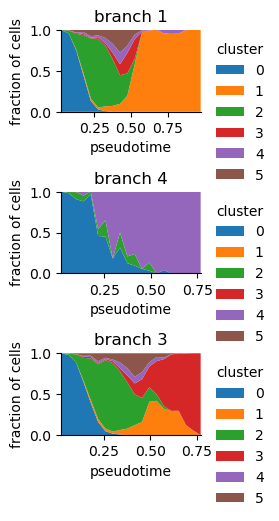

In [19]:
branches = list(rna.obsm['branch_masks'].columns)
fig, axes = plt.subplots(3,1, figsize=(3,5), sharey=False)
axes = axes.flatten()
freqs = {b: plot_pseudotime_cluster_freq(rna, branch=b, n_bins=20, ax=ax)
         for b, ax in zip(branches, axes)}
fig.tight_layout()
fig.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_trajectory_binned_cluster_freq.pdf'), bbox_inches='tight')

# CellRank: Kernel and Estimator

In [20]:
pk = cr.kernels.PseudotimeKernel(rna, time_key='palantir_pseudotime')
pk.compute_transition_matrix()
pk

INFO     Computing transition matrix based on pseudotime                                                           


  0%|          | 0/19121 [00:00<?, ?cell/s]

INFO         Finish (3.30s)                                                                                        


PseudotimeKernel[n=19121, dnorm=False, scheme='hard', frac_to_keep=0.3]

INFO     Computing Schur decomposition                                                                             
[1788368400.669971] [isca098:2786759:0]        ib_iface.c:1363 UCX  ERROR mlx5_2: ibv_create_cq(cqe=4096) failed: Cannot allocate memory : Please set max locked memory (ulimit -l) to 'unlimited' (current: 64 kbytes)
[1788368400.669988] [isca098:2786759:0]      ucp_worker.c:1415 UCX  ERROR uct_iface_open(rc_verbs/mlx5_2:1) failed: Input/output error


[isca098.mskcc.org:2786759] pml_ucx.c:319  Error: Failed to create UCP worker


INFO     When computing macrostates, choose a number of states NOT in ``                                           
INFO     Adding `adata.uns['eigendecomposition_fwd']`                                                              
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                                                              
             Finish (2.31s)                                                                                        


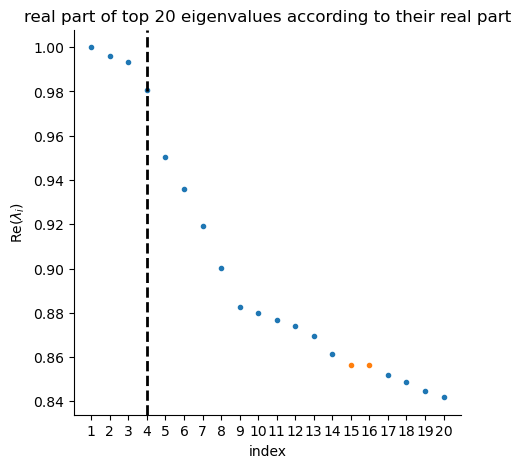

In [21]:
g = cr.estimators.GPCCA(pk)
g.compute_schur(n_components=20)
g.plot_spectrum(real_only=True)
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_eigengap.pdf'), bbox_inches='tight')

Inspect the eigengap above to choose the number of macrostates, then fit and predict terminal/initial states automatically (no clusters hard-coded).

INFO     Computing 5 macrostates                                                                                   
INFO     Adding `.macrostates`                                                                                     
                `.macrostates_memberships`                                                                         
                `.coarse_T`                                                                                        
                `.coarse_initial_distribution                                                                      
                `.coarse_stationary_distribution`                                                                  
                `.schur_vectors`                                                                                   
                `.schur_matrix`                                                                                    
                `.eigendecomposition`                                   

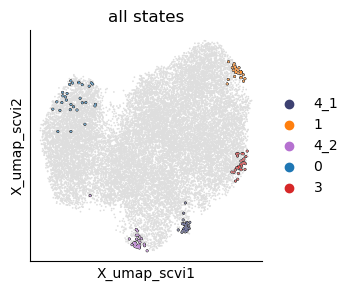

<Figure size 300x300 with 0 Axes>

In [22]:
n_states = 5  # update based on the eigengap plot above
g.compute_macrostates(n_states=n_states, cluster_key='leiden_0.5')
g.plot_macrostates(which='all', basis='X_umap_scvi', legend_loc='right',
                   save=os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_macrostates.pdf'))

INFO     Adding `adata.obs['term_states_fwd']`                                                                     
                `adata.obs['term_states_fwd_probs']`                                                               
                `.terminal_states`                                                                                 
                `.terminal_states_probabilities`                                                                   
                `.terminal_states_memberships                                                                      
             Finish`                                                                                               


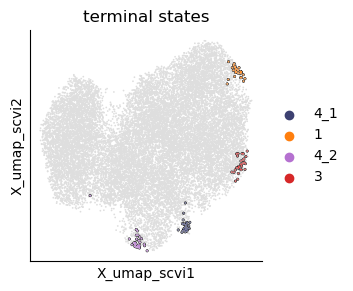

<Figure size 300x300 with 0 Axes>

In [23]:
g.predict_terminal_states()
g.plot_macrostates(which='terminal', basis='X_umap_scvi', legend_loc='right',
                   save=os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_terminal_states.pdf'))

INFO     Adding `adata.obs['init_states_fwd']`                                                                     
                `adata.obs['init_states_fwd_probs']`                                                               
                `.initial_states`                                                                                  
                `.initial_states_probabilities`                                                                    
                `.initial_states_memberships                                                                       
             Finish`                                                                                               


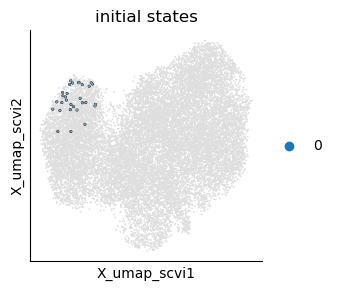

In [24]:
g.predict_initial_states()
g.plot_macrostates(which='initial', basis='X_umap_scvi', legend_loc='right')

## Map discovered terminal states onto leiden clusters

Since terminal states were discovered automatically, check how they correspond to `leiden_0.5` clusters before interpreting fate probabilities.

In [25]:
rna.obs['cellrank_terminal_state'] = g.terminal_states
term_states = rna.obs['cellrank_terminal_state'].cat.categories.tolist()
crosstab = pd.crosstab(rna.obs['cellrank_terminal_state'], rna.obs['leiden_0.5'], normalize='index')
crosstab

leiden_0.5,0,1,3,4,5
cellrank_terminal_state,,,,,
4_1,0.000000,0.0,0.0,0.966667,0.033333
1,0.000000,1.0,0.0,0.000000,0.000000
4_2,0.033333,0.0,0.0,0.966667,0.000000
3,0.000000,0.0,1.0,0.000000,0.000000


# Fate Probabilities

INFO     Computing fate probabilities                                                                              


  0%|          | 0/4 [00:00<?, ?/s]

INFO     Adding `adata.obsm['lineages_fwd']`                                                                       
                `.fate_probabilities`                                                                              
             Finish (0.15s)                                                                                        
INFO     Solving TSP for `4` states                                                                                


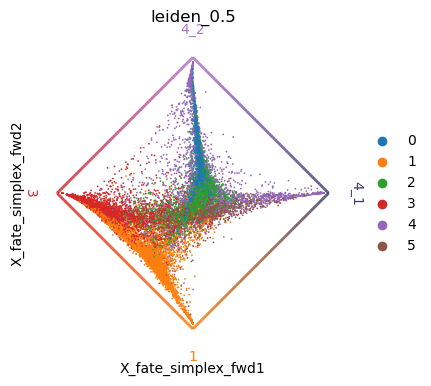

In [26]:
g.compute_fate_probabilities()
cr.pl.circular_projection(rna, keys='leiden_0.5', legend_loc='right')
plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_circular_projection.pdf'), bbox_inches='tight')

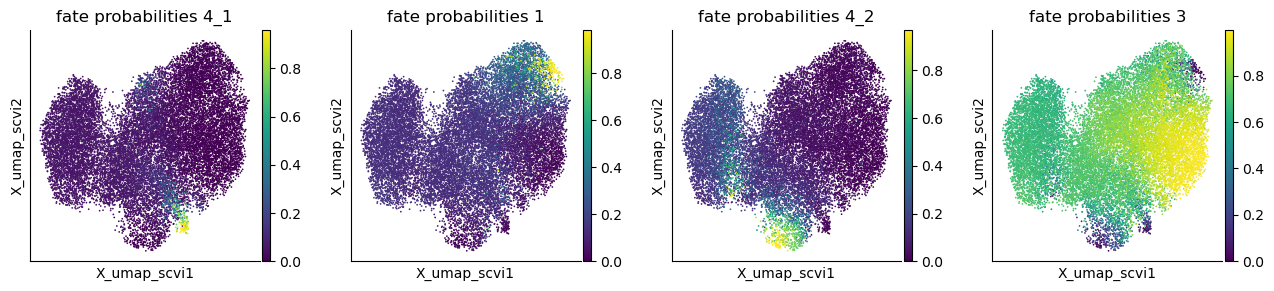

<Figure size 300x300 with 0 Axes>

In [27]:
g.plot_fate_probabilities(basis='X_umap_scvi', same_plot=False,
                          save=os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_fate_probabilities_umap.pdf'))

# Is Cluster 2 a Transitory State?

If cluster 2 is transitory, its cells should sit at intermediate pseudotime between the initial state and clusters 1/3.

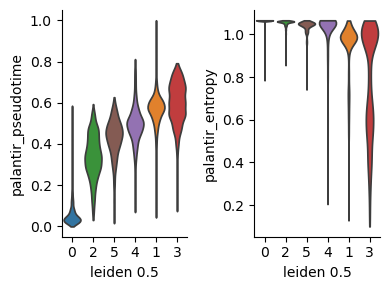

In [28]:
fig, ax = plt.subplots(1,2, figsize=(4,3))
sc.pl.violin(rna, keys=['palantir_pseudotime'], groupby='leiden_0.5', stripplot=False, ax=ax[0],
             order=['0','2','5','4','1','3'], show=False)
sc.pl.violin(rna, keys=['palantir_entropy'], groupby='leiden_0.5', stripplot=False, ax=ax[1], 
             order=['0','2','5','4','1','3'], show=False)
plt.tight_layout()
fig.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_palantir_pseudotime_violin.pdf'), bbox_inches='tight')

# Gene Trends for Ikzf2 (Helios) and Gata3

Update `lineages_of_interest` below once the cluster-to-terminal-state mapping above identifies which discovered terminal states correspond to clusters 1 and 3.

In [29]:
rna

AnnData object with n_obs × n_vars = 19121 × 12055
    obs: 'tissue', 'n_genes_by_counts', 'total_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'pct_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'log1p_total_counts_ribo', 'log10_genes_per_umi', 'S_score', 'G2M_score', 'phase', 'n_counts', 'n_genes', 'doublet_score', 'predicted_doublet', 'hashtag_code', 'cage', 'mouse', 'treatment', 'leiden', 'experiment', 'sex', 'leiden_0.5', 'leiden_1.0', 'leiden_1.5', 'leiden_2.0', 'leiden_0.75', 'activity_TGFB1_IL21_c', 'activity_TGFB1_TNFSF18_c', 'activity_TGFB1_IL4_c', 'activity_IL27_IL18_c', 'activity_IL21_IL1B_c', 'activity_TNF_CCL19_c', 'activity_IL21_CCL21A_c', 'activity_IL7_TNFSF18_c', 'activity_IL4_CCL19_c', 'activity_IL2_TNFSF4_c', 'activity_IL6_TNFSF18_c', 'activity_IL2_TNFSF18_c', 'activity_IL4_TNFSF18_c', 'activity_TNF_TNFSF4_c', 'activity_IL2_IFNB1_c', 'activity_IL4_IFNB1_c', 'activity_IL27_TNF_c', 'activity_TNF_IFNB1_c', 'ac

INFO     Computing trends using 1 core(s)                                                                          


  0%|          | 0/2 [00:00<?, ?gene/s]

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/distributions.py:490: RuntimeWarning: divide by zero encountered in log
  dev = 2 * ((y - mu) / mu - np.log(y / mu))
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/pygam.py:1150: RuntimeWarning: invalid value encountered in scalar divide
  r2["explained_deviance"] = 1.0 - full_d.sum() / null_d.sum()
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/pygam.py:1151: RuntimeWarning: invalid value encountered in scalar divide
  r2["McFadden"] = full_ll / null_ll
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/pygam.py:1152: RuntimeWarning: invalid value encountered in scalar divide
  r2["McFadden_adj"] = 1.0 - (full_ll - self.statistics_["edof"]) / null_ll
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/distributions.py:490: RuntimeWarning: divide by zero encountered in lo

INFO         Finish (0.70s)                                                                                        
INFO     Plotting trends                                                                                           


/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/distributions.py:490: RuntimeWarning: divide by zero encountered in log
  dev = 2 * ((y - mu) / mu - np.log(y / mu))
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pygam/pygam.py:1150: RuntimeWarning: invalid value encountered in scalar divide
  r2["explained_deviance"] = 1.0 - full_d.sum() / null_d.sum()


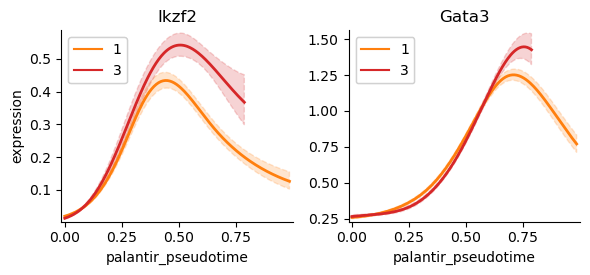

In [30]:
lineages_of_interest = ['1','3']

model = cr.models.GAM(rna)
cr.pl.gene_trends(
    rna,
    model=model,
    genes=['Ikzf2','Gata3'],
    same_plot=True,
    hide_cells=True,
    lineages=lineages_of_interest,
    time_key='palantir_pseudotime',
    data_key='log1p_norm',
    ncols=2,
    figsize=(6, 3)
)

plt.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_gene_trends_Ikzf2_Gata3.pdf'), bbox_inches='tight')

# Gene Trends for Activity Scores

`cr.pl.gene_trends` can also fit a per-cell `.obs` covariate (e.g. a signaling activity score) instead of gene expression, by passing `cellrank.models.Obs('obs_column_name')` in the `signals` list. `Obs` and gene names/`Gene(...)` can be mixed in the same call. Update the `activity_...` column names below to the scores of interest.

INFO     Computing trends using 1 core(s)                                                                          


  0%|          | 0/3 [00:00<?, ?obs/s]

INFO         Finish (0.20s)                                                                                        
INFO     Plotting trends                                                                                           


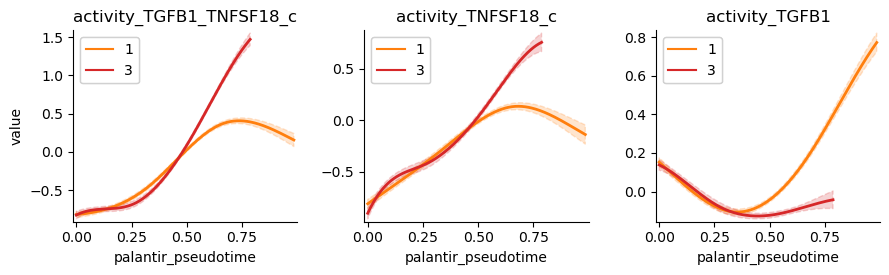

In [39]:
lineages_of_interest = ['1','3']

activity_signals = [
    cr.models.Obs('activity_TGFB1_TNFSF18_c'),
    cr.models.Obs('activity_TNFSF18_c'),
    cr.models.Obs('activity_TGFB1'),
]

# activity scores can be negative, so use a Gaussian/identity-link GAM
# instead of the default gamma/log-link model (which requires y >= 0)
activity_model = cr.models.GAM(rna, distribution='gaussian', link='identity')

# return_figure=True hands back the Figure (and its .axes) instead of
# cr.pl.gene_trends plotting/saving directly, so it can be treated as a
# subpanel and tweaked (size, titles, ticks, etc.) before it's finalized
fig = cr.pl.gene_trends(
    rna,
    model=activity_model,
    signals=activity_signals,
    same_plot=True,
    hide_cells=True,
    lineages=lineages_of_interest,
    time_key='palantir_pseudotime',
    ncols=3,
    figsize=(9, 3),
    return_figure=True,
)
fig.tight_layout()
# fig.set_size_inches(10, 6)

fig.savefig(os.path.join(output_dir,'SIG19_DTR_iLN_cellrank_gene_trends_activity_scores.pdf'), bbox_inches='tight')